# Assignment 2

In this assigment, we will work with the *Adult* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult). Extract the data files into the subdirectory: `../05_src/data/adult/` (relative to `./05_src/`).

# Load the data

Assuming that the files `adult.data` and `adult.test` are in `../05_src/data/adult/`, then you can use the code below to load them.

In [2]:
import pandas as pd
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week',
    'native-country', 'income'
]
adult_dt = (pd.read_csv('../../05_src/data/adult/adult.data', header = None, names = columns)
              .assign(income = lambda x: (x.income.str.strip() == '>50K')*1))


In [3]:
adult_dt.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


# Get X and Y

Create the features data frame and target data:

+ Create a dataframe `X` that holds the features (all columns that are not `income`).
+ Create a dataframe `Y` that holds the target data (`income`).
+ From `X` and `Y`, obtain the training and testing data sets:

    - Use a train-test split of 70-30%. 
    - Set the random state of the splitting function to 42.

In [10]:
# keep all columns but income
X = adult_dt.drop(columns=['income'])
#keep only the income column
Y = adult_dt[['income']]

# check columns names
print(X.columns.values,
      Y.columns.values)
print(X.shape,
      Y.shape)

['age' 'workclass' 'fnlwgt' 'education' 'education-num' 'marital-status'
 'occupation' 'relationship' 'race' 'sex' 'capital-gain' 'capital-loss'
 'hours-per-week' 'native-country'] ['income']
(32561, 14) (32561, 1)


In [12]:
# import some libraries
from sklearn.model_selection import train_test_split

In [13]:
# set training and test splits
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

# check sizing is correct
print(X_train.shape, X_test.shape,
      Y_train.shape, Y_test.shape)

(22792, 14) (9769, 14) (22792, 1) (9769, 1)


## Random States

Please comment: 

+ What is the [random state](https://scikit-learn.org/stable/glossary.html#term-random_state) of the [splitting function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)? 
+ Why is it [useful](https://en.wikipedia.org/wiki/Reproducibility)?

The random state of the splitting function is 42, and is listed as the command random_state = 42. This is important to consider because the code and results are replicable. Anyone who has access to the same data would be able to recreate the same results and ensure we used correct methodology, or ensure the code was ran correctly, by getting the same results as well. 

# Preprocessing

Create a [Column Transformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) that treats the features as follows:

- Numerical variables

    * Apply [KNN-based imputation for completing missing values](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html):
        
        + Consider the 7 nearest neighbours.
        + Weight each neighbour by the inverse of its distance, causing closer neigbours to have more influence than more distant ones.
    * [Scale features using statistics that are robust to outliers](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html#sklearn.preprocessing.RobustScaler).

- Categorical variables: 
    
    * Apply a [simple imputation strategy](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer):

        + Use the most frequent value to complete missing values, also called the *mode*.

    * Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html):
        
        + Handle unknown labels if they exist.
        + Drop one column for binary variables.
    
    
The column transformer should look like this:

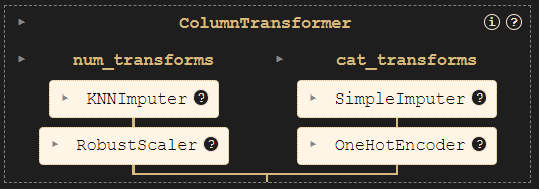

In [16]:
# import some more libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

In [41]:
# step1 - set the numerical cols and cat cols
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# step2 - the knn imputation for numeric variables
knn_impute = Pipeline([
    ('imputer', KNNImputer(n_neighbors=7, weights = 'distance')), # ensure we use 7 neighbours and weighted by distance
    ('standardizer', RobustScaler()) # use the robust scaler for our standardizer
])

# step3 - simple imputation for categorical variables
cats_simple = Pipeline([
    ('cat_imputer', SimpleImputer(strategy = 'most_frequent')), # use the most frequent value to replace
    ('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary'))
])

# step4 - create the columns transformer with our two pipelines
ctransform = ColumnTransformer([
    ('num_transforms', knn_impute, num_cols),
    ('cat_transforms', cats_simple, cat_cols)
])

ctransform

ColumnTransformer(transformers=[('num_transforms',
                                 Pipeline(steps=[('imputer',
                                                  KNNImputer(n_neighbors=7,
                                                             weights='distance')),
                                                 ('standardizer',
                                                  RobustScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week']),
                                ('cat_transforms',
                                 Pipeline(steps=[('cat_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='infrequent_if_exist'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country'])])

## Model Pipeline

Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `classifier` and assign a [`RandomForestClassifier()`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) to it.

The pipeline looks like this:

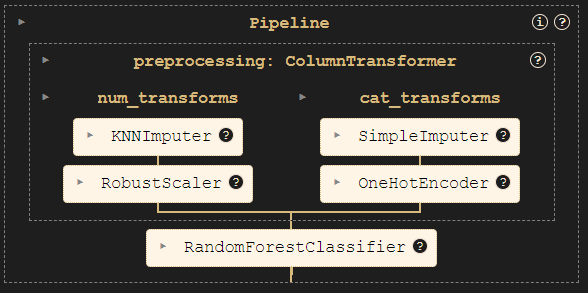

In [26]:
# import some libraries
from sklearn.ensemble import RandomForestClassifier

In [43]:
# create the pipeline
pipe_transform = Pipeline([
    ('preprocessing', ctransform),
    ('classifier', RandomForestClassifier())
])

pipe_transform

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7,
                                                                              weights='distance')),
                                                                  ('standardizer',
                                                                   RobustScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier', RandomForestClassifier())])

# Cross-Validation

Evaluate the model pipeline using [`cross_validate()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html):

+ Measure the following [preformance metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#common-cases-predefined-values): negative log loss, ROC AUC, accuracy, and balanced accuracy.
+ Report the training and validation results. 
+ Use five folds.


In [44]:
# import libraries
from sklearn.model_selection import cross_validate

In [62]:
# set the scoring parameters
scoring = ['neg_log_loss', 'roc_auc', 'accuracy', 'balanced_accuracy']

# create the cross validation
adult_cv = cross_validate(pipe_transform, X_train, Y_train, cv = 5, scoring = scoring, return_train_score=True)

adult_cv

c:\Users\Alexander\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\Alexander\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Alexander\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Alexander\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

{'fit_time': array([11.88703012, 13.45012236, 14.27146673, 15.43207812, 14.40544009]),
 'score_time': array([0.23480988, 0.2802906 , 0.2729342 , 0.31098318, 0.27669477]),
 'test_neg_log_loss': array([-0.36549564, -0.36750496, -0.38275338, -0.3649092 , -0.38115693]),
 'train_neg_log_loss': array([-0.08141665, -0.08174984, -0.08131974, -0.08203007, -0.08161859]),
 'test_roc_auc': array([0.90361305, 0.90189808, 0.90147671, 0.90607813, 0.90209864]),
 'train_roc_auc': array([0.99999998, 1.        , 1.        , 1.        , 1.        ]),
 'test_accuracy': array([0.85259925, 0.84821233, 0.85454147, 0.85805178, 0.85651602]),
 'train_accuracy': array([0.99989031, 1.        , 1.        , 1.        , 1.        ]),
 'test_balanced_accuracy': array([0.7788603 , 0.77043326, 0.77692177, 0.78108471, 0.77791729]),
 'train_balanced_accuracy': array([0.99977381, 1.        , 1.        , 1.        , 1.        ])}

Display the fold-level results as a pandas data frame and sorted by negative log loss of the test (validation) set.

In [64]:
# creating the pandas dataframe
adult_cv_df = pd.DataFrame(adult_cv)

# sort by negative log loss
adult_cv_df = adult_cv_df.sort_values(by='test_neg_log_loss', ascending=False)
adult_cv_df

,fit_time,score_time,test_neg_log_loss,train_neg_log_loss,test_roc_auc,train_roc_auc,test_accuracy,train_accuracy,test_balanced_accuracy,train_balanced_accuracy
3,15.432078,0.310983,-0.364909,-0.082030,0.906078,1.0,0.858052,1.00000,0.781085,1.000000
0,11.887030,0.234810,-0.365496,-0.081417,0.903613,1.0,0.852599,0.99989,0.778860,0.999774
1,13.450122,0.280291,-0.367505,-0.081750,0.901898,1.0,0.848212,1.00000,0.770433,1.000000
4,14.405440,0.276695,-0.381157,-0.081619,0.902099,1.0,0.856516,1.00000,0.777917,1.000000
2,14.271467,0.272934,-0.382753,-0.081320,0.901477,1.0,0.854541,1.00000,0.776922,1.000000


Calculate the mean of each metric. 

In [65]:
# calculate mean of each metric
adult_cv_df.mean()

fit_time                   13.889227
score_time                  0.275143
test_neg_log_loss          -0.372364
train_neg_log_loss         -0.081627
test_roc_auc                0.903033
train_roc_auc               1.000000
test_accuracy               0.853984
train_accuracy              0.999978
test_balanced_accuracy      0.777043
train_balanced_accuracy     0.999955
dtype: float64

Calculate the same performance metrics (negative log loss, ROC AUC, accuracy, and balanced accuracy) using the testing data `X_test` and `Y_test`. Display results as a dictionary.

*Tip*: both, `roc_auc()` and `neg_log_loss()` will require prediction scores from `pipe.predict_proba()`. However, for `roc_auc()` you should only pass the last column `Y_pred_proba[:, 1]`. Use `Y_pred_proba` with `neg_log_loss()`.

In [60]:
# import libraries
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, balanced_accuracy_score

In [53]:
# fit pipeline to train data
pipe_transform.fit(X_train, Y_train)

c:\Users\Alexander\miniconda3\envs\dsi_participant\lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer(n_neighbors=7,
                                                                              weights='distance')),
                                                                  ('standardizer',
                                                                   RobustScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='infrequent_if_exist'))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country'])])),
                ('classifier', RandomForestClassifier())])

In [55]:
# Create prediction data from x and y test
Y_pred_train = pipe_transform.predict(X_train)
Y_pred_test = pipe_transform.predict(X_test)

# create the probability data as well
Y_proba_train = pipe_transform.predict_proba(X_train)
Y_proba_test = pipe_transform.predict_proba(X_test)

In [56]:
# review some of the data to make sure it looks good
print(Y_pred_train, Y_proba_test)

[0 1 0 ... 0 0 0] [[1.   0.  ]
 [0.49 0.51]
 [0.3  0.7 ]
 ...
 [0.99 0.01]
 [0.43 0.57]
 [0.01 0.99]]


In [72]:
# generate our testing results
results = {
    'log_loss_train' : log_loss(Y_train, Y_proba_train) * (-1),
    'roc_train' : roc_auc_score(Y_train, Y_proba_train[:, 1]),
    'accuracy_score_train': accuracy_score(Y_train, Y_pred_train),
    'balanced_accuracy_score_train': balanced_accuracy_score(Y_train, Y_pred_train),
    'log_loss_test': log_loss(Y_test, Y_proba_test) * (-1),
    'roc_test': roc_auc_score(Y_test, Y_proba_test[:, 1]),
    'accuracy_score_test': accuracy_score(Y_test, Y_pred_test),
    'balanced_accuracy_score_test': balanced_accuracy_score(Y_test, Y_pred_test)
}

results

{'log_loss_train': -0.08127355656050728,
 'roc_train': 1.0,
 'accuracy_score_train': 0.999956124956125,
 'balanced_accuracy_score_train': 0.9999095350099512,
 'log_loss_test': -0.3638757314727421,
 'roc_test': 0.9013895820906423,
 'accuracy_score_test': 0.8539256832838571,
 'balanced_accuracy_score_test': 0.7737623087994983}

# Target Recoding

In the first code chunk of this document, we loaded the data and immediately recoded the target variable `income`. Why is this [convenient](https://scikit-learn.org/stable/modules/model_evaluation.html#binary-case)?

The specific line was:

```
adult_dt = (pd.read_csv('../05_src/data/adult/adult.data', header = None, names = columns)
              .assign(income = lambda x: (x.income.str.strip() == '>50K')*1))
```

The recoding of the target variable 'income' was necessary.  

First, this was a binary classification model. We needed to create an outcome variable with either 0 or 1 as the outcome to act as the binary flag. This is necessary for the packages used such as the model classifier and the scoring modules.  

Next, the conversion into the binary classifier early on in the file, makes it consistent for the rest of the script. In that case, there are no instances where we need to recode variables for the classifier because one split of the dataset is different from the other. Instead, all datasets that use income is now either 1 or 0 based on the initial split.  

This first line was convenient because it ensures the data remains consistent for the entire analytics and is necessary for analytics packages that are used. 

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Becker,Barry and Kohavi,Ronny. (1996). Adult. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.